In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(w):
    x, y = w
    return 100*x**2 + y**2

def grad(w):
    x, y = w
    return np.array([200*x, 2*y])

def hessian(w):
    return np.array([[200, 0],
                     [0, 2]])

In [3]:
def gradient_step(w, lr):
    return w - lr * grad(w)

def newton_step(w):
    H = hessian(w)
    g = grad(w)

    return w - np.linalg.solve(H, g)

With one global learning rate:

Good for steep direction OR good for flat direction
Hard to be good for both simultaneously.

That’s why curvature-aware methods matter.

In [4]:
# Gradient descent path
def run_gd(start, lr=0.01, steps=20):
    w = np.array(start, dtype=float)
    path = [w.copy()]
    
    for _ in range(steps):
        w = gradient_step(w, lr)
        path.append(w.copy())
    
    return np.array(path)

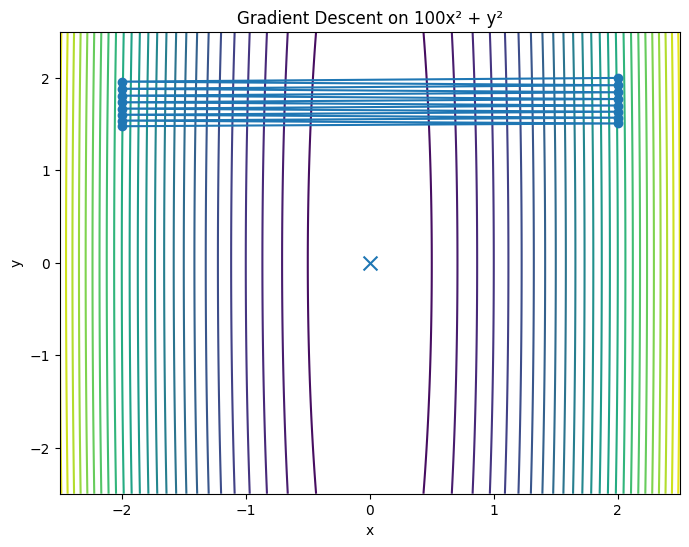

In [8]:
# Run
path = run_gd(start=(2,2), lr=0.01, steps=15)

# Grid for contour
x = np.linspace(-2.5, 2.5, 400)
y = np.linspace(-2.5, 2.5, 400)
X, Y = np.meshgrid(x, y)
Z = 100*X**2 + Y**2

# Plot
plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=30)
plt.plot(path[:,0], path[:,1], marker='o')
plt.scatter([0], [0], s=100, marker='x')
plt.title("Gradient Descent on 100x² + y²")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [9]:
def f(w):
    x, y = w
    return 10*x**2 + y**2

def grad(w):
    x, y = w
    return np.array([20*x, 2*y])

Z = 10*X**2 + Y**2

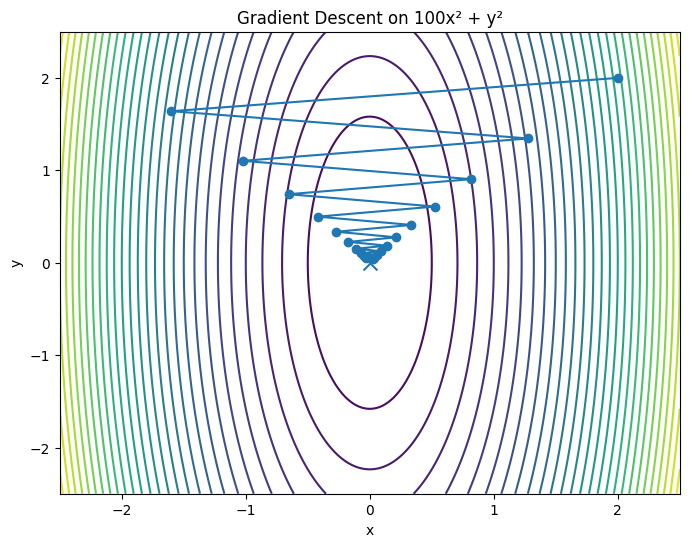

In [11]:
# Run
path = run_gd(start=(2,2), lr=0.09, steps=20)

# Grid for contour
x = np.linspace(-2.5, 2.5, 400)
y = np.linspace(-2.5, 2.5, 400)
X, Y = np.meshgrid(x, y)

# Plot
plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=30)
plt.plot(path[:,0], path[:,1], marker='o')
plt.scatter([0], [0], s=100, marker='x')
plt.title("Gradient Descent on 100x² + y²")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [12]:
def run_momentum(start, lr=0.09, beta=0.9, steps=20):
    w = np.array(start, dtype=float)
    v = np.zeros_like(w)
    path = [w.copy()]
    
    for _ in range(steps):
        v = beta * v - lr * grad(w)
        w = w + v
        path.append(w.copy())
        
    return np.array(path)

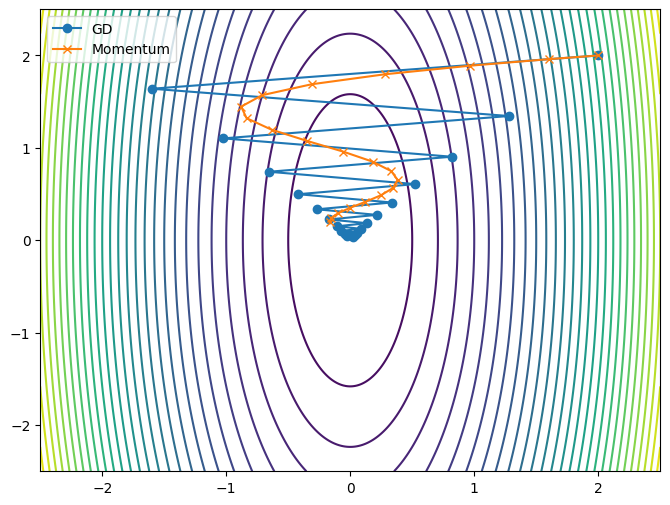

In [19]:
gd_path = run_gd((2,2), lr=0.09, steps=20)
mom_path = run_momentum((2,2), lr=0.01, beta=0.78, steps=20)

plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=30)

plt.plot(gd_path[:,0], gd_path[:,1], marker='o', label='GD')
plt.plot(mom_path[:,0], mom_path[:,1], marker='x', label='Momentum')

plt.legend()
plt.show()